# Gaussian Mixture Model

<from scikit-learn.org>
-  Probabilistic model that assumes all the data points are generated from a mixture of 
a finite number of Gaussian distributions with unknown parameters
-  Generalizing k-means clustering incorporate covariance structure of the data as well as the centers

In [2]:
import pandas as pd 
  # pandas numpy
import numpy as np
import matplotlib.pyplot as plt
  # seaborn  plotly
import seaborn as sns; sns.set()

### data generation

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.datasets.samples_generator module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.datasets. Anything that cannot be imported from sklearn.datasets is now part of the private API.
  warnings.warn(message, FutureWarning)


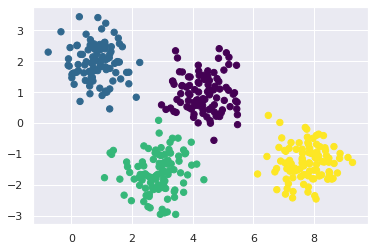

In [3]:
# Generate some data
from sklearn.datasets.samples_generator import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] # flip axes for better plotting(?)

plt.scatter(X[:, 0], X[:, 1], c=y_true, s=40, cmap='viridis');

### K-Means Clustering: not assigning clustering-assigning probability

In [18]:
from sklearn.mixture import GaussianMixture as GMM
gmm = GMM(n_components=4).fit(X)
labels = gmm.predict(X)

In [19]:
probs = gmm.predict_proba(X)
print(probs[:5].round(3))

[[0.463 0.537 0.    0.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    0.    1.   ]]


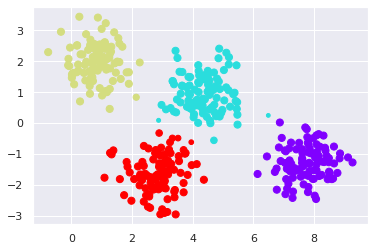

In [20]:
size = 50 * probs.max(1) ** 2  
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=size);

***Question: What's the probability of 'ball-like points' to be in purple zone or yellow zone?***
-  Seems to overlap between middle clusters 
-  k-means model has no intrinsic measure of probability or uncertainty of cluster assignments 

- Transformed data are not circular 
- Hence K-mean has two shortcomings:
    -  lack of flexibility in cluster shape 
    -  lack of probabilistic cluster assignment

###  Gaussian Mixture Model: 

***Gaussian Mixture Model***
-  Gaussain Mixture model is based on weighted sum of $M$ component's Gaussian density
\begin{align*}
p(\mathbf{x}|~\lambda) = \sum_{i=1}^{M} \omega_i g(\mathbf{x}~&|~\mu_i, \Sigma_i) \\
        where &\sum \omega_i =1,~~ \mathbf{x}:~~ feature~~ matrix,~~  g(\mathbf{x}~|~\mu_i, \Sigma_i):~ Gaussian~~ density \\
&   g(\mathbf{x}~|~\mu_i, \Sigma_i)=\frac{1}{(2\pi)^{1/2} |\Sigma_i|^{1/2}}
                 exp\{\frac{1}{2} (\mathbf{x}-\mu_i)'\Sigma_i^{-1}(\mathbf{x}-\mu_i)\}
\end{align*}

-  Hence the parameter to be estimated are:
\begin{equation*}
\lambda = (\omega_i, \mu_i , \Sigma_i)
\end{equation*}

***Gaussian Mixture: Covariance Issues***

- type: Spherical, Diagonal, full 
\begin{align*}
    &\Sigma(Spherical) = \sigma^2 I \\
    &\Sigma(Diagonal) = \mathbf{\mathit{diag}}(\sigma_1^2, \sigma_2^2, \cdots, \sigma_D^2)\\
    &\Sigma(full) = 
     \begin{bmatrix} \sigma^2_1&\sigma_{12}&\sigma_{13}&\cdots&\sigma_{1D}\\
                 \sigma_{21}&\sigma_{22}&\cdots&&\sigma_{2D} \\
                 \vdots&\vdots&\cdots&&\vdots \\
                 \sigma_{D1}&\sigma_{D2}&\cdots&&\sigma_{DD} \\
                         \end{bmatrix}\\
    &\Sigma(tied)=\text{the same covariance matrix is shared by all the Gaussians}      
\end{align*}

-  $\textbf{Full}$ means the components may independently adopt any position and shape.

-  $\textbf{Tied}$ means they have the same shape, but the shape may be anything.
   -  the contour axes are oriented along the coordinate axes

-  $\textbf{Diagonal}$ means the contour axes are oriented along the coordinate axes, but otherwise the eccentricities may vary between components.

-  $\textbf{Spherical}$ is a "diagonal" situation with circular contours (spherical in higher dimensions, whence the name).

 `def _check_precisions(precisions, covariance_type, n_components, n_features):
            """Validate user provided precisions.`

`parameters'
            ----------
            precisions : array-like,
                'full' : shape of (n_components, n_features, n_features)
                'tied' : shape of (n_features, n_features)
                'diag' : shape of (n_components, n_features)
                'spherical' : shape of (n_components,)

            covariance_type : string`
        

***Gaussian Mixture Model's pros and cons***
- pros: Speedy and model selection based on statistical criteria
- cons: covariance matrix estimation is difficult when nobs is large

***Gaussian Mixture Model's Algorithm***
-  EM Algorithm

***Model Selection Criteria***
-  BIC (Bayesian Information Criterion)
-  AIC (Akaike Information Criterion)

### GMM with Simulated Data

In [21]:
# Generate  data
from sklearn.datasets.samples_generator import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] 

In [22]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4)
gmm.fit(X)
label = gmm.predict(X)

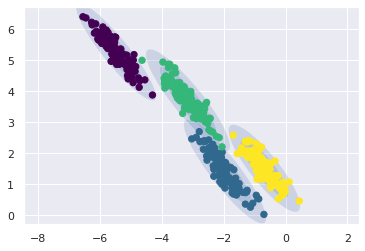

In [23]:
# Generate  data
from sklearn.datasets.samples_generator import make_blobs
from sklearn.mixture import GaussianMixture
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] 

# Instanciation
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)


# data pertubation
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))


plot_gmm(gmm, X_stretched)

### GMM: covariance shape

In [ ]:
np.degrees(np.arctan2(U[1, 0], U[0, 0]))
# the signed angle in radians between the ray ending 
# at the origin and passing through the point (1,0), 
# and the ray ending at the origin and
# passing through the point (U[0,0], U[1,0])


array([-112.50283434,   -9.98744795])

-  ***How to convert covariance to axes?*** <br>
&nbsp; &nbsp;&nbsp;For single value decomposion [Click Here](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.linalg.svd.html)  <br>
&nbsp; &nbsp;&nbsp;For SVD in Wiki[Click Here](https://en.wikipedia.org/wiki/Singular-value_decomposition)

-  ***Conjugate Transpose***

$$
\begin{aligned}
    A= 
         \begin{bmatrix} 
                 1& -2-i& \\
                 1+i &i & 
         \end{bmatrix} ,~~~~~~
    A^H =     
         \begin{bmatrix} 
                 1& 1-i& \\
                 -2 + i &-i & 
         \end{bmatrix}
\end{aligned}
$$ 

- $\textbf{Normal}$: $A\cdot A^H = A^H \cdotA$ <br>
- $\textbf{Unitary}$: $A^H = A^{-1}$
- $\textbf{Conjugate or Hermitian}$: $A = A^{H}$
    -  Conjugate: $A^c = det(A) A^{-1}$

-  *** SVD (Sigularity-Value Decomposition)***   
\begin{align*}
M_{m\times n} &= U_{m\times m}\Sigma_{m\times n} V^*_{n \times n} \\
&\text{where}~~ U=\text{unitary matrix},~~ \Sigma=\text{rectangular diagonal matrix},~~ V=\text{unitary matrix} \\
& \text{diagonal elements}~~ \sigma_i~~ in~~ \Sigma~~ called~~ \mathbf{\text{Singular Values of}}~~ M,\\
& U, V~~ \mathbf{\text{Singular Vector of M}}
\end{align*}

- SVD caluclation
  -  The non-zero singular values of M (found on the diagonal entries of $\Sigma$) are the square roots of the non-zero eigenvalues of both $M^H M$ and $MM^H$.
  -  The left-singular vectors of $M$ are a set of orthonormal eigenvectors of $MM^H$
  -  The right-singular vectors of $M$ are a set of orthonormal eigenvectors of $M^H M$
 

***What is plot_gmm?***

In [11]:
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle, **kwargs))


def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)

### GMM as denstity estimation

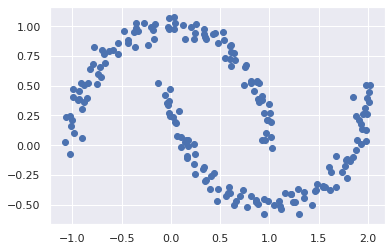

In [25]:
from sklearn.datasets import make_moons
Xmoon, ymoon = make_moons(200, noise=.05, random_state=0)
plt.scatter(Xmoon[:, 0], Xmoon[:, 1], label=True);

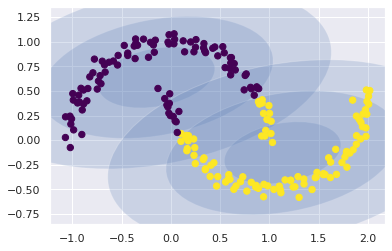

In [15]:
from sklearn.mixture import GaussianMixture as GMM 
gmm2 = GMM(n_components=2, covariance_type='full', random_state=0)
plot_gmm(gmm2, Xmoon)

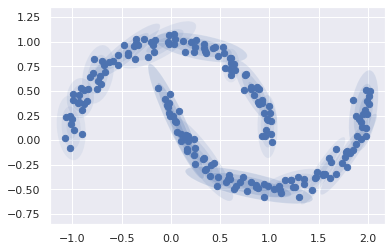

In [16]:
gmm16 = GMM(n_components=16, covariance_type='full', random_state=0)
plot_gmm(gmm16, Xmoon, label=False)

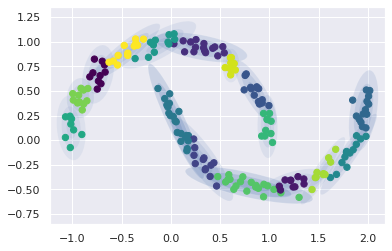

In [24]:
plot_gmm(gmm16, Xmoon)

### Model selection criteria

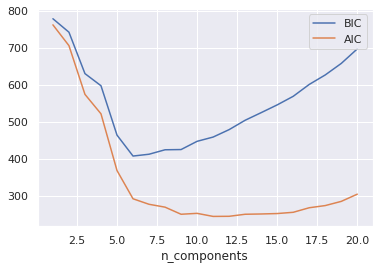

In [17]:
n_components = np.arange(1, 21)
models = [GMM(n, covariance_type='full', random_state=0).fit(Xmoon)
          for n in n_components]

plt.plot(n_components, [m.bic(Xmoon) for m in models], label='BIC')
plt.plot(n_components, [m.aic(Xmoon) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

-  *** 8-12 components are enough***

### GMM as data generator
-  load data: load_digits
-  rank reduction using PCA
- regenerate data ($x_{new}$)using estimated PCA
- $x_{new}$ is estimated using GMM
- Using AIC or BIC to choose components and generate data ($x_{new\_gmm}$)
- convert $x_{new\_gmm}$ into new digits 
- to see whether new digits are plausible with eyeballs